In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')

Device: cuda
Số ảnh train: 60000,  test: 10000


In [28]:
train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)), # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Reinitialize train_dataset with the new transform
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=train_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

print('Train dataset updated with data augmentation.')

Train dataset updated with data augmentation.


In [6]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [8]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/5  train_loss=0.1823  train_acc=94.30%  test_loss=0.0633  test_acc=97.90%
Epoch 2/5  train_loss=0.0651  train_acc=98.06%  test_loss=0.0567  test_acc=98.15%
Epoch 3/5  train_loss=0.0494  train_acc=98.48%  test_loss=0.0413  test_acc=98.74%
Epoch 4/5  train_loss=0.0423  train_acc=98.70%  test_loss=0.0495  test_acc=98.52%
Epoch 5/5  train_loss=0.0370  train_acc=98.82%  test_loss=0.0416  test_acc=98.64%


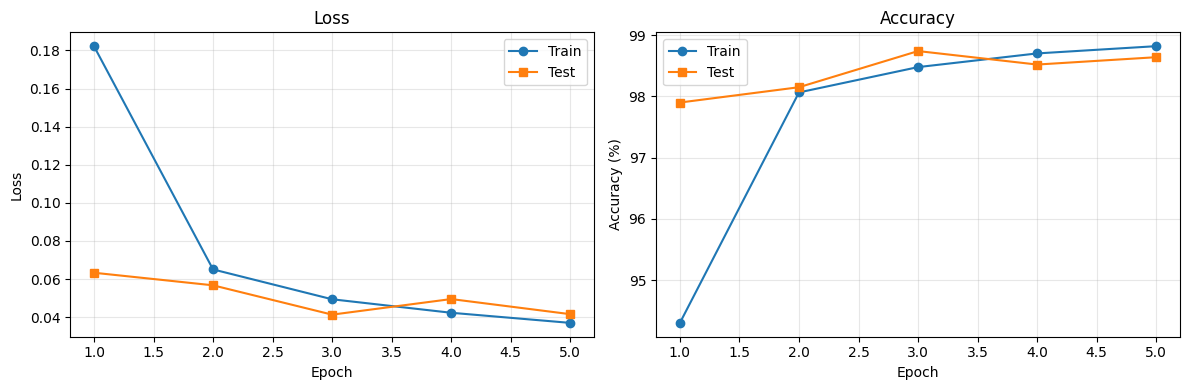

In [9]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()


In [10]:
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

Final test accuracy: 98.64%
(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)


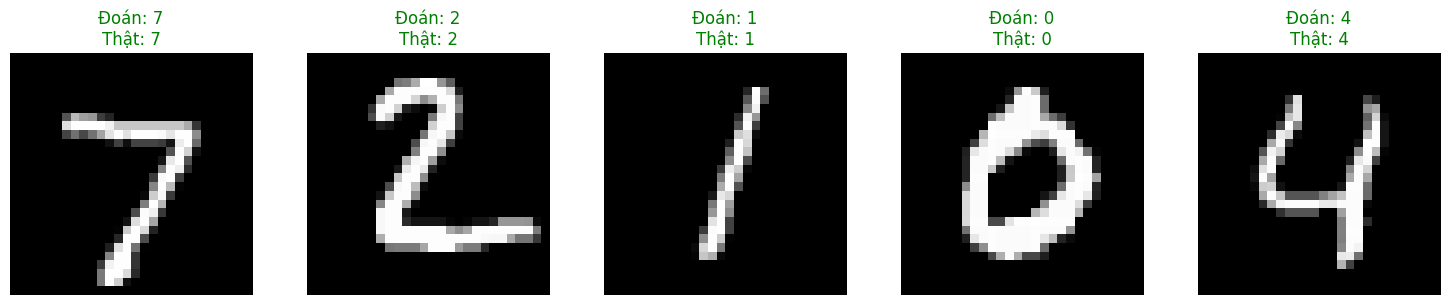

In [11]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()


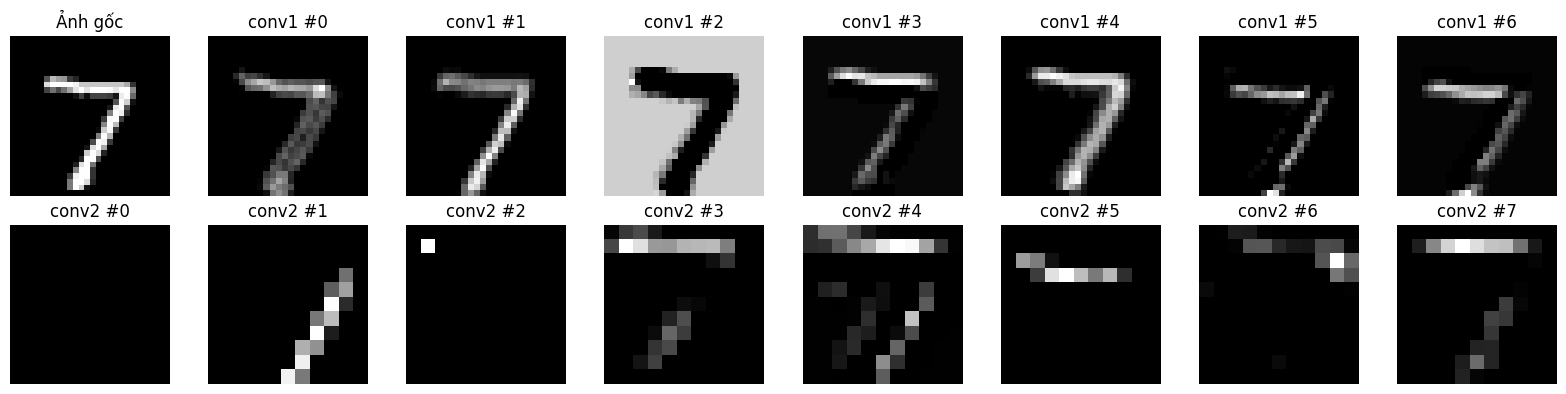

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [12]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

BTVN

CAU1

In [13]:
num_epochs = 10

CAU2

In [26]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1) # Thêm mới
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25) # Dropout layer
        self.fc1 = nn.Linear(64 * 2 * 2, 10) # Cập nhật kích thước input

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x))) # Thêm mới
        x = x.view(x.size(0), -1)
        x = self.dropout(x) # Apply dropout before the final layer
        x = self.fc1(x)
        return x

CAU3

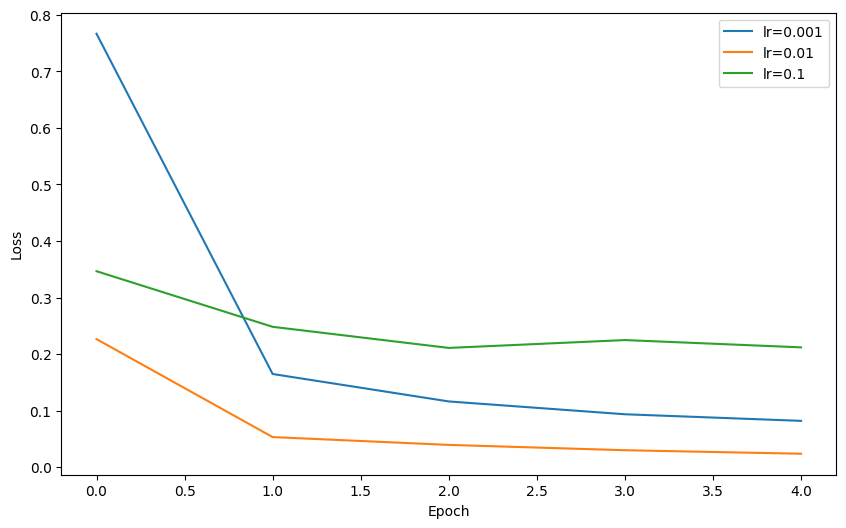

In [24]:
learning_rates = [0.001, 0.01, 0.1]
all_loss_histories = []

for lr in learning_rates:
    # 1. Khởi tạo lại model và optimizer với lr hiện tại
    model = MNIST_CNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    # 2. Huấn luyện (giữ nguyên logic train 5 epoch của bạn)
    # Lưu ý: cần thu thập loss của từng epoch vào một danh sách riêng
    loss_history = []
    for epoch in range(5):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)

        train_loss = running_loss / total
        loss_history.append(train_loss)

    all_loss_histories.append(loss_history)

# 3. Vẽ đồ thị
plt.figure(figsize=(10, 6))
for i, lr in enumerate(learning_rates):
    plt.plot(all_loss_histories[i], label=f'lr={lr}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

CAU4

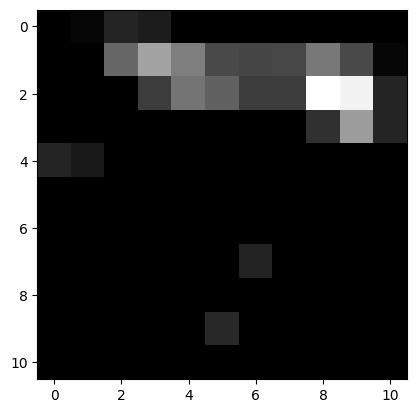

In [19]:
# Lấy một batch từ test_loader để test
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    h1 = torch.relu(model.conv1(images))
    h1 = model.pool(h1)
    h2 = torch.relu(model.conv2(h1)) # Đây là feature map của conv2

# Vẽ kênh đầu tiên của ảnh đầu tiên trong batch
plt.imshow(h2[0, 0].cpu().numpy(), cmap='gray')
plt.show()

CAU5

In [32]:
# Cập nhật dataset với transform tương ứng
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

# Cập nhật DataLoader
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


# Khởi tạo mô hình với cấu trúc mới
model = MNIST_CNN().to(device)

# Khởi tạo lại optimizer nếu cần (để reset trọng số)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)